In [21]:
# Importar paquetes y algoritmos
import numpy as np
import pandas as pd
from pathlib import Path
import sys
import os

sys.path.insert(0, os.path.abspath(os.path.join('../src')))

from pyoma2.algorithms.fdd import FDD_MS
from pyoma2.algorithms.ssi import SSIdat_MS, SSIcov_MS
from pyoma2.algorithms.fdd import EFDD_MS
from pyoma2.setup import MultiSetup_PreGER
from pyoma2.functions.gen import MAC
from pyoma2.functions.plot import plot_mac_matrix


In [22]:
# Cargado de registros
set1 = np.loadtxt(r'Torre_Schell_16_08_2025 14_03_30.txt', delimiter='\t')
set2 = np.loadtxt(r'Torre_Schell_16_08_2025 13_27_59.txt', delimiter='\t')

# Definiendo variable de data e índices de referencia
datasets = [set1, set2]
ref_indices = [
    [3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20],  # for dataset 0 (set1)
    [3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20],  # for dataset 1 (set2)
]

print('Setup 1',set1)
print('Setup 2',set2)

Setup 1 [[-1.52833504e-03 -5.67452796e-03 -3.99009109e-01 ...  4.32469230e-03
  -9.93676600e-04 -3.98914218e-01]
 [ 4.13940754e-04  1.09561719e-03  8.15004110e-02 ... -8.42211768e-04
  -1.11449277e-04  8.14338923e-02]
 [-3.72918323e-04 -7.77068548e-04 -3.69108915e-02 ...  5.96626662e-04
  -3.00135813e-04 -3.68856788e-02]
 ...
 [ 3.45828010e-05 -1.88265927e-04  4.49240208e-04 ...  1.15230680e-04
  -3.07374634e-04  2.50101089e-04]
 [-1.15283760e-05 -2.33078375e-04  5.16414642e-04 ...  2.08423473e-04
  -3.52863455e-04  5.14805317e-04]
 [-2.42732698e-04 -1.71711668e-04  7.65919690e-05 ...  1.14839524e-04
  -3.73137533e-04  2.43008137e-04]]
Setup 2 [[-1.83457998e-03 -5.98453078e-03 -3.98780942e-01 ...  4.42915689e-03
  -1.00074662e-03 -3.98850024e-01]
 [ 1.57651026e-04  8.37552361e-04  8.12865496e-02 ... -9.73099843e-04
  -4.47360800e-05  8.12394619e-02]
 [-3.01925233e-04 -6.54444098e-04 -3.70740891e-02 ...  4.35495749e-04
  -2.19606794e-04 -3.69727612e-02]
 ...
 [ 8.83089380e-05 -1.2125540

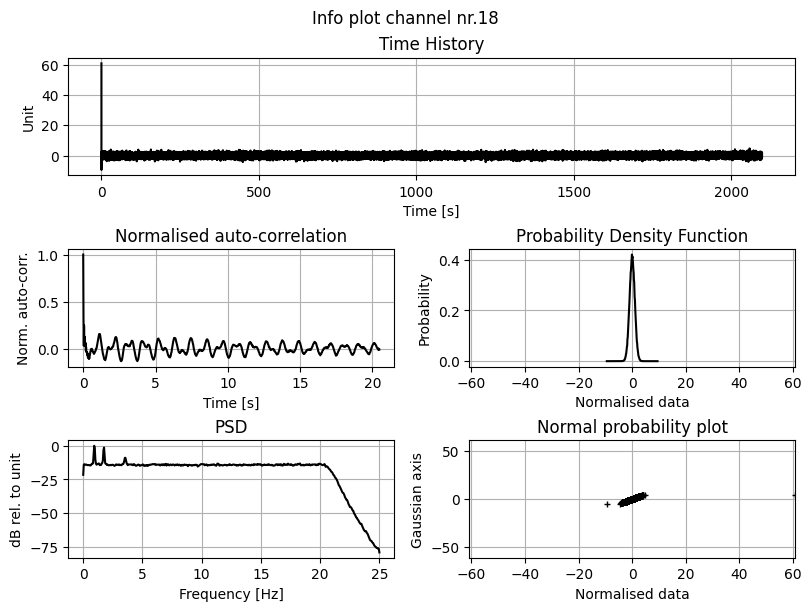

In [23]:
# Parámetros data
f = 100      # Hz
q = 2        # Decimación f/q
f_low = .5  # Hz

# MS_PreGER 
ms = MultiSetup_PreGER(fs=f, ref_ind=ref_indices, datasets=datasets)
ms.decimate_data(q=q)
ms.filter_data(f_low, order=4, btype='highpass')

# Ploteo para verificar data
_, _ = ms.plot_ch_info(data_idx=[0], ch_idx=[18])

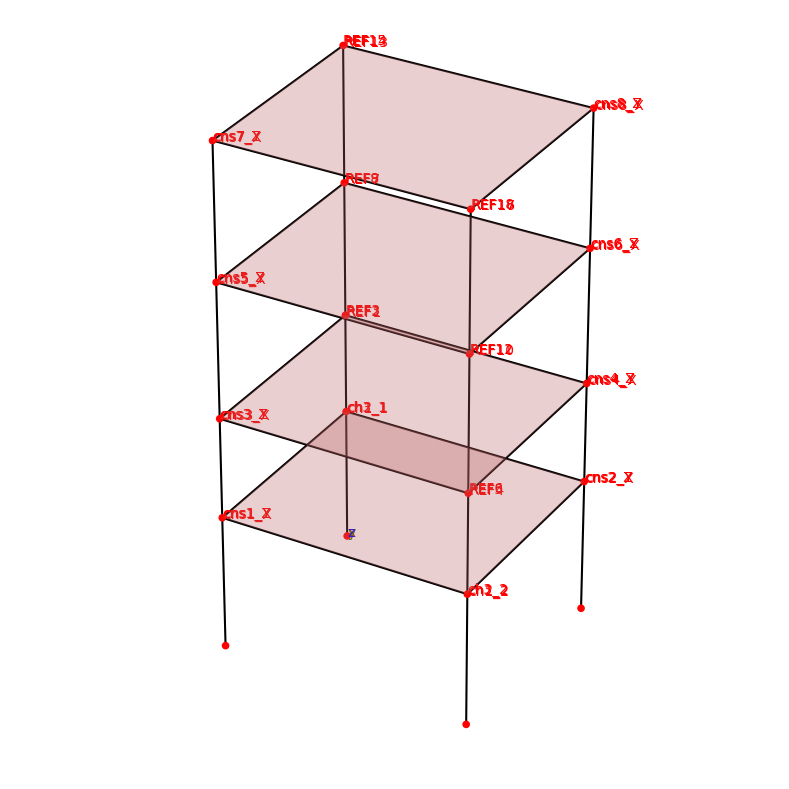

In [24]:
# Lectura de archivo
geo_path = Path(r"Geo_TorreSchell.xlsx")
xls = pd.ExcelFile(geo_path, engine='openpyxl')

# Asignación de geometrías
ms.def_geo2_by_file(xls)

_, _ = ms.plot_geo2_mpl(scaleF=0.1)

In [25]:
algo_ssidat = SSIdat_MS(name='SSIdat_MS', calc_unc=True, br=80, ordmax=100, step=1)
algo_ssicov = SSIcov_MS(name='SSIcov_MS', calc_unc=True, br=80, ordmax=100, step=1)
algo_efdd = EFDD_MS(name='EFDD_MS', nxseg=2**11, method_SD='per', pov=1)
algo_fdd = FDD_MS(name="FDD_MS",nxseg=1024, method_SD="cor")
# Corrida de algoritmos
ms.add_algorithms(algo_ssidat, algo_ssicov, algo_efdd, algo_fdd)
ms.run_all()

2025-08-19 16:25:55,084 - pyoma2.setup.base - INFO - Running SSIdat_MS... (base:123)
100%|██████████| 101/101 [00:00<00:00, 5865.10it/s]
2025-08-19 16:27:02,949 - pyoma2.functions.ssi - INFO - Calculating modal parameters for increasing model order... (ssi:486)
100%|██████████| 101/101 [00:00<00:00, 188.45it/s]
2025-08-19 16:27:04,336 - pyoma2.setup.base - INFO - Running SSIcov_MS... (base:123)
100%|██████████| 101/101 [00:00<00:00, 7162.72it/s]
2025-08-19 16:27:13,091 - pyoma2.functions.ssi - INFO - Calculating modal parameters for increasing model order... (ssi:486)
100%|██████████| 101/101 [00:00<00:00, 182.80it/s]
2025-08-19 16:27:14,547 - pyoma2.setup.base - INFO - Running EFDD_MS... (base:123)
100%|██████████| 2/2 [00:01<00:00,  1.12it/s]
2025-08-19 16:27:16,504 - pyoma2.setup.base - INFO - Running FDD_MS... (base:123)
100%|██████████| 2/2 [00:01<00:00,  1.13it/s]
2025-08-19 16:27:18,366 - pyoma2.setup.base - INFO - all done (base:102)


In [26]:
# get the executed algorithm (must be executed-alg object inside the setup)
exe_alg_ssidat = ms.algorithms['SSIdat_MS']
exe_alg_ssicov = ms.algorithms['SSIcov_MS']
exe_alg_efdd = ms.algorithms['EFDD_MS']
exe_alg_fdd = ms.algorithms['FDD_MS']

# now call the picker and capture its return
ms.mpe_from_plot('SSIdat_MS', freqlim=(0,20))
ms.mpe_from_plot('SSIcov_MS', freqlim=(0,20))
ms.mpe_from_plot('EFDD_MS', freqlim=(0,20))
ms.mpe_from_plot('FDD_MS', freqlim=(0,20))

# Get modal shapes (Φ) from each algorithm's results
phi_ssidat = exe_alg_ssidat.result.Phi  # shape: (nDOF, nModes)
phi_ssicov = exe_alg_ssicov.result.Phi
phi_efdd   = exe_alg_efdd.result.Phi
phi_fdd   = exe_alg_fdd.result.Phi

# RESULTADOS
print("_______________________________________________\n"," ")

# Print resultados SSIdat
print("- SSIdat")
print("Orden de modelo:\n",exe_alg_ssidat.result.order_out)
#print("Formas",phi_ssidat)
print("Frecuencias (Hz):\n",exe_alg_ssidat.result.Fn)
print("Amortiguamiento:\n",exe_alg_ssidat.result.Xi)

print("_______________________________________________\n"," ")

# Print resultados SSIcov
print("- SSIcov")
print("Orden de modelo:\n",exe_alg_ssicov.result.order_out)
#print("Formas",phi_ssicov)
print("Frecuencias (Hz):\n",exe_alg_ssicov.result.Fn)
print("Amortiguamiento:\n",exe_alg_ssicov.result.Xi)

print("_______________________________________________\n"," ")

# Print resultados EFDD
print("EFDD")
#print("Formas\n",phi_efdd)
print("Frecuencias\n",exe_alg_efdd.result.Fn)
print("Amortiguamiento\n",exe_alg_efdd.result.Xi)

print("_______________________________________________\n"," ")

# Print resultados FDD
print("FDD")
#print("Formas\n",phi_fdd)
print("Frecuencias\n",exe_alg_fdd.result.Fn)
#print("Amortiguamiento\n",exe_alg_fdd.result.)

print("_______________________________________________\n"," ")

2025-08-19 16:27:18,381 - pyoma2.setup.base - INFO - Getting mpe modal parameters from plot... SSIdat_MS (base:171)
2025-08-19 16:27:26,095 - pyoma2.functions.ssi - INFO - Extracting SSI modal parameters (ssi:889)
100%|██████████| 4/4 [00:00<00:00, 4006.02it/s]
2025-08-19 16:27:26,099 - pyoma2.setup.base - INFO - Getting mpe modal parameters from plot... SSIcov_MS (base:171)
2025-08-19 16:27:31,985 - pyoma2.functions.ssi - INFO - Extracting SSI modal parameters (ssi:889)
100%|██████████| 4/4 [00:00<?, ?it/s]
2025-08-19 16:27:31,989 - pyoma2.setup.base - INFO - Getting mpe modal parameters from plot... EFDD_MS (base:171)
2025-08-19 16:27:41,672 - pyoma2.functions.fdd - INFO - Extracting FDD modal parameters (fdd:284)
100%|██████████| 3/3 [00:00<?, ?it/s]
2025-08-19 16:27:41,675 - pyoma2.functions.fdd - INFO - Extracting EFDD modal parameters (fdd:492)
100%|██████████| 3/3 [00:00<00:00,  9.58it/s]
2025-08-19 16:27:41,992 - pyoma2.setup.base - INFO - Getting mpe modal parameters from plot

_______________________________________________
  
- SSIdat
Orden de modelo:
 [44 43 43 43]
Frecuencias (Hz):
 [0.93156337 1.3162817  1.74045082 3.49027211]
Amortiguamiento:
 [0.01242849 0.01028918 0.00608347 0.02023673]
_______________________________________________
  
- SSIcov
Orden de modelo:
 [42 42 42 42]
Frecuencias (Hz):
 [0.93987709 1.3226614  1.7443007  3.53482731]
Amortiguamiento:
 [0.00764479 0.00725248 0.00525991 0.01297456]
_______________________________________________
  
EFDD
Frecuencias
 [0.9422571  1.31883346 1.74305044]
Amortiguamiento
 [0.02719369 0.015643   0.01891974]
_______________________________________________
  
FDD
Frecuencias
 [0.43945312 0.87890625 1.46484375 1.5625    ]
_______________________________________________
  


<Figure size 640x480 with 0 Axes>

_______________________________________________
  
1. Diagrama de estabilización SSIdat
2. Diagrama de estabilización SSIcov



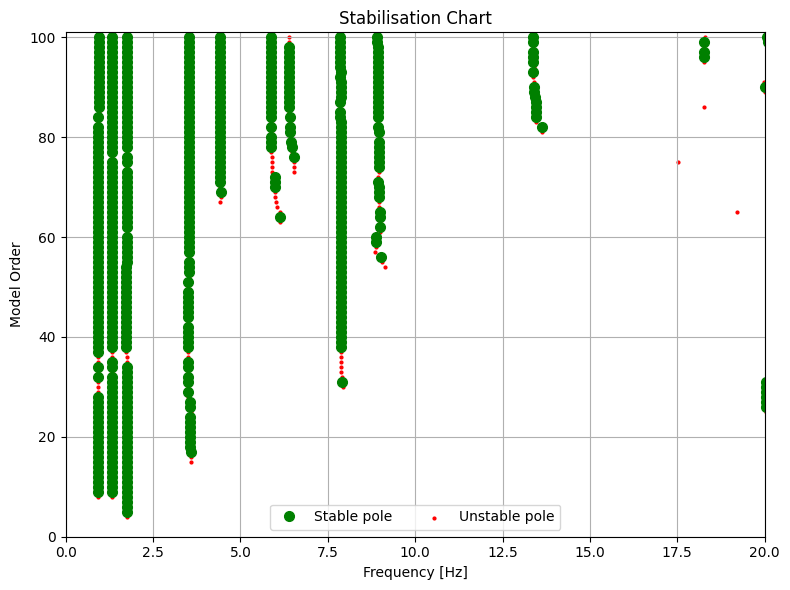

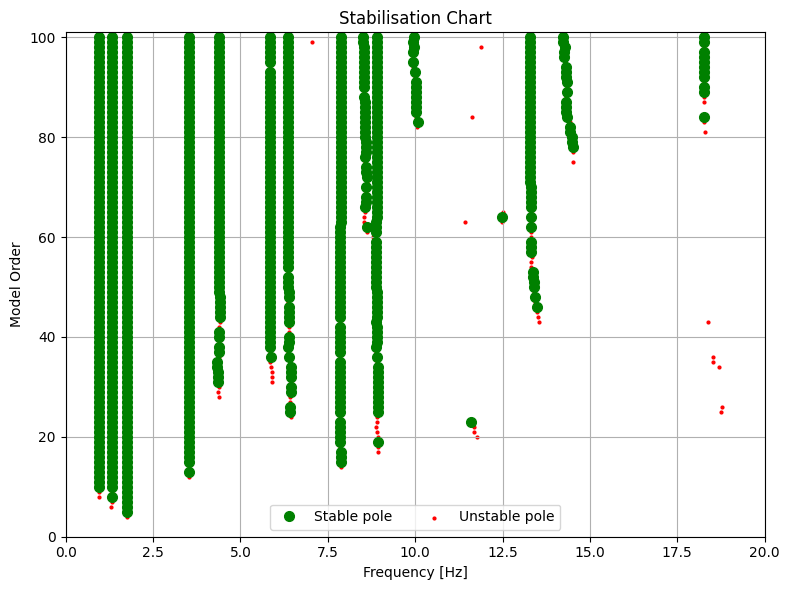

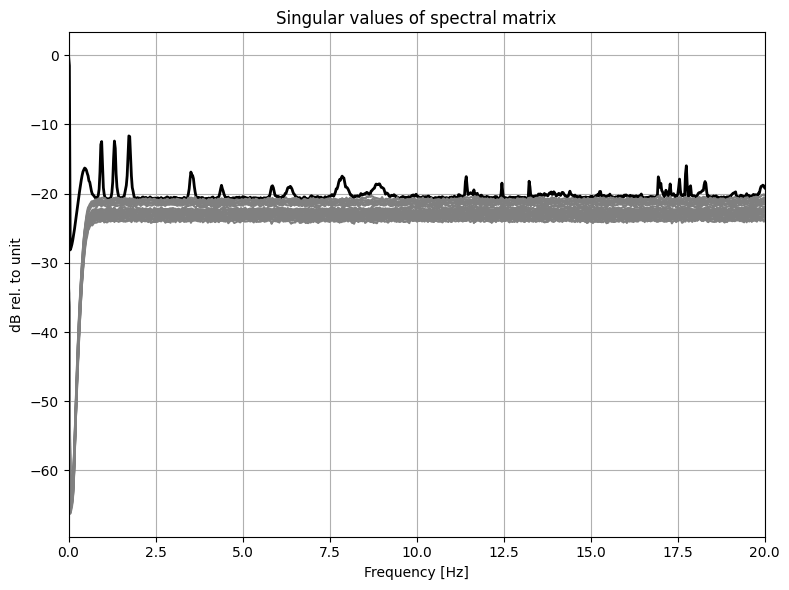

In [27]:
# plot diagrams (optional but helpful)
print("_______________________________________________\n"," ")
print("1. Diagrama de estabilización SSIdat")
std_SSI_dat = exe_alg_ssidat.plot_stab(freqlim=(0,20), hide_poles=False)
print("2. Diagrama de estabilización SSIcov")
std_SSI_cov = exe_alg_ssicov.plot_stab(freqlim=(0,20), hide_poles=False)
#print("3. Descomposición de valores singulares EFDD")
svd_EFDD = exe_alg_efdd.plot_CMIF(freqlim=(0,20))
print("")

In [34]:
# Animación de los modos

#SSI_dat
modei = 2
anim1 = ms.anim_mode_geo2(algo_res=exe_alg_ssidat.result, mode_nr=modei, scaleF=5,def_sett={"cmap":"jet"})

#SSI_cov
modej = 2
anim2 = ms.anim_mode_geo2(algo_res=exe_alg_ssicov.result, mode_nr=modej, scaleF=5,def_sett={"cmap":"jet"})

#EFDD
modek = 2
anim3 = ms.anim_mode_geo2(algo_res=exe_alg_efdd.result, mode_nr=modek, scaleF=5,def_sett={"cmap":"jet"})

#EFDD
modeh = 2
anim3 = ms.anim_mode_geo2(algo_res=exe_alg_fdd.result, mode_nr=modeh, scaleF=5,def_sett={"cmap":"jet"})

In [29]:
print(phi_ssidat)

[[ 0.44610306+1.36168703e-02j -0.03503696+2.01265293e-02j
   0.28658869-2.46904726e-02j  0.99391616+1.70156335e-02j]
 [ 0.04176227-3.26031472e-03j  0.37030482-8.78557720e-03j
   0.43126303-1.10732669e-02j  0.07000015-1.41655708e-02j]
 [-0.01421574-9.26274087e-03j -0.08378356+5.24181732e-03j
  -0.11665141+1.05488789e-03j -0.03489341-2.15436879e-03j]
 [ 0.46193484-1.48808327e-02j -0.00126025+8.75313558e-03j
  -0.29882663+3.02673052e-03j  1.        +0.00000000e+00j]
 [ 0.02479179-8.04458510e-03j  0.40447549-3.13785601e-02j
  -0.38524967+1.91800169e-02j  0.06416449+4.99139095e-02j]
 [ 0.00861735-6.80792055e-06j  0.05447301+7.78774878e-03j
  -0.0863733 +4.23826234e-03j  0.04920443+3.65222214e-02j]
 [ 0.75784596-1.91483160e-03j -0.0901183 +1.64648160e-04j
  -0.48481045+1.18135388e-02j  0.31532756+3.48199537e-02j]
 [ 0.09419709-1.56542694e-02j  0.74453542-2.56709723e-02j
  -0.75450271+2.13885518e-03j -0.02411857+3.01599674e-02j]
 [ 0.0462354 -2.84613891e-02j  0.09785776+7.80220999e-03j
  -0.0

In [30]:
np.size(phi_ssidat, axis = 0)

24

In [31]:
print(phi_fdd)

[[-0.00759126-1.39314789e-05j -0.00759403+1.48619059e-05j
  -0.00758358+7.36174225e-06j -0.00759667+6.54655524e-06j]
 [ 0.01655636-1.21785049e-05j  0.01656286+5.89955415e-06j
   0.01656971+7.34597735e-06j  0.01658655+2.60803094e-05j]
 [ 0.99917468+1.82134189e-05j  0.99914882+6.06068333e-07j
   0.99918968-4.72074081e-06j  0.9991414 +4.16855279e-06j]
 [ 0.00794427+2.72886689e-05j  0.00793614+1.48288232e-05j
   0.00793243+2.13847531e-05j  0.00793441+3.71166216e-06j]
 [-0.00876901+6.22618707e-06j -0.00877028-1.81373435e-05j
  -0.00878965+1.48941098e-05j -0.0088062 -7.79057846e-06j]
 [ 0.99964016-2.14789786e-05j  0.99960993-4.02811830e-05j
   0.99970291-4.30673335e-05j  0.9996909 +3.02539892e-05j]
 [ 0.01123225-8.62551057e-06j  0.01123683+8.16197503e-06j
   0.01120563-8.09444865e-06j  0.01122437-4.95708360e-05j]
 [-0.00637036-7.90862381e-06j -0.00636943-4.65343076e-06j
  -0.00640422-2.37584191e-05j -0.00638987-5.89021627e-05j]
 [ 0.99940273+3.57532998e-06j  0.99937223-1.24276905e-07j
   0.9